In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

In [2]:
DATA_PATH = "data/session_combined_l1_l2_bin_features_umap_clusters_300_20_full_sessions.csv"

session_df = pd.read_csv(
    DATA_PATH,
    parse_dates=["session_start", "session_end"],
)

print("users:", session_df["user_id"].nunique())
print("sessions:", session_df["session_id"].nunique())
print("shape:", session_df.shape)

session_df.head()

users: 14976
sessions: 17817
shape: (17817, 644)


,user_id,session_id,session_start,session_end,session_number,l1_l2_pattern_id,representative_session_id,is_representative_pattern_session,n_sessions_with_same_l1_l2_pattern,umap_1,...,l2_youtube_leather_strap_hat_black,l2_youtube_pen_2pack,l2_youtube_play_mug,l2_youtube_small_sticker_sheet,l2_youtube_standards_zip_hoodie_black,l2_youtube_standards_zip_hoodie_black_xs,l2_youtube_tee_black,l2_youtube_transmission_journal_black,l2_youtube_transmission_journal_red,l2_youtube_twill_cap_sandwich_black
0,1.001303e+06,1001303.4827739208_1,2021-01-06 16:50:51.058662,2021-01-06 16:59:45.540877,1,0,1001303.4827739208_1,True,1,0.427278,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.001330e+06,1001330.4092774704_1,2021-01-27 06:11:34.783632,2021-01-27 06:29:28.852303,1,1,1001330.4092774704_1,True,1,1.130339,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.001844e+06,1001844.0963402748_1,2021-01-09 04:05:53.350957,2021-01-09 04:07:50.418985,1,2,1001844.0963402748_1,True,1,0.096430,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.003861e+06,1003861.0959917124_1,2021-01-15 18:12:48.846800,2021-01-15 18:14:11.723659,1,3,1003861.0959917124_1,True,15,4.158210,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.003881e+06,1003880.5623994712_1,2021-01-08 02:46:54.118599,2021-01-08 02:47:15.121745,1,4,1003880.5623994712_1,True,634,6.765485,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


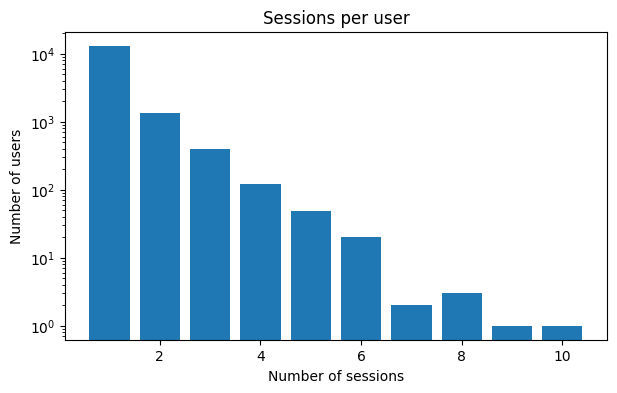

In [3]:
user_session_counts = (
    session_df
    .groupby("user_id")["session_id"]
    .nunique()
    .reset_index(name="n_sessions")
)

session_count_distribution = (
    user_session_counts["n_sessions"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))
plt.bar(session_count_distribution.index, session_count_distribution.values)
plt.yscale("log")
plt.xlabel("Number of sessions")
plt.ylabel("Number of users")
plt.title("Sessions per user")
plt.show()

In [4]:
min_sessions = 3

session_df_filtered = (
    session_df
    .query("cluster != -1")
    .copy()
    .reset_index(drop=True)
)

user_session_counts = (
    session_df_filtered
    .groupby("user_id")["session_id"]
    .nunique()
    .reset_index(name="n_sessions")
)

valid_users = user_session_counts.loc[
    user_session_counts["n_sessions"] > min_sessions,
    "user_id",
]

session_df_filtered = (
    session_df_filtered[session_df_filtered["user_id"].isin(valid_users)]
    .copy()
    .reset_index(drop=True)
)

user_session_counts_filtered = (
    session_df_filtered
    .groupby("user_id")["session_id"]
    .nunique()
    .reset_index(name="n_sessions")
)

print("users with more than", min_sessions, "non-noise sessions:", session_df_filtered["user_id"].nunique())
print("sessions kept:", session_df_filtered["session_id"].nunique())
print("filtered shape:", session_df_filtered.shape)

users with more than 3 non-noise sessions: 159
sessions kept: 727
filtered shape: (727, 644)


In [5]:
def cluster_entropy(clusters):
    counts = pd.Series(clusters).value_counts()

    if counts.empty:
        return np.nan

    p = counts / counts.sum()
    return float(-(p * np.log2(p)).sum())


def safe_minmax(s):
    s = pd.Series(s, dtype="float")
    span = s.max() - s.min()

    if pd.isna(span) or span == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)

    return (s - s.min()) / span


def trajectory_features(user_id, grp):
    sort_cols = [
        col for col in ["session_start", "session_number", "session_id"]
        if col in grp.columns
    ]

    grp = (
        grp
        .sort_values(sort_cols, na_position="last")
        .drop_duplicates(subset=["session_id"])
        .copy()
    )

    coords = grp[["umap_1", "umap_2"]].to_numpy(dtype=float)
    clusters = grp["cluster"].to_numpy()

    diffs = np.diff(coords, axis=0)
    step_distances = (
        np.linalg.norm(diffs, axis=1)
        if len(coords) > 1
        else np.array([])
    )

    path_length = float(step_distances.sum()) if len(step_distances) else 0.0
    mean_step_distance = float(step_distances.mean()) if len(step_distances) else np.nan

    territory = (
        float(coords.std(axis=0).mean())
        if len(coords) > 1
        else 0.0
    )

    return {
        "user_id": user_id,
        "n_sessions": grp["session_id"].nunique(),
        "cluster_entropy": cluster_entropy(clusters),
        "path_length": path_length,
        "mean_step_distance": mean_step_distance,
        "territory": territory,
    }

In [6]:
trajectory_user_df = pd.DataFrame(
    trajectory_features(user_id, grp)
    for user_id, grp in session_df_filtered.groupby("user_id")
)

trajectory_user_df["trajectory_score"] = safe_minmax(
    trajectory_user_df["territory"]
)

support_features = [
    "cluster_entropy",
    "path_length",
    "mean_step_distance",
]

scaled_support_features = []
for feature in support_features:
    scaled_col = f"{feature}_scaled"
    trajectory_user_df[scaled_col] = safe_minmax(trajectory_user_df[feature])
    scaled_support_features.append(scaled_col)

trajectory_user_df.head()

,user_id,n_sessions,cluster_entropy,path_length,mean_step_distance,territory,trajectory_score,cluster_entropy_scaled,path_length_scaled,mean_step_distance_scaled
0,1.240985e+06,4,0.811278,4.213118,1.404373,1.150683,0.436797,0.405639,0.109685,0.185708
1,1.442352e+06,4,1.500000,12.074943,4.024981,2.186924,0.830153,0.750000,0.314361,0.532246
2,1.484258e+06,4,1.500000,4.376340,1.458780,0.768817,0.291842,0.750000,0.113935,0.192903
3,1.612807e+06,10,1.295462,38.411016,4.267891,2.424753,0.920433,0.647731,1.000000,0.564368
4,1.636779e+06,4,2.000000,10.764316,3.588105,2.097432,0.796182,1.000000,0.280240,0.474476


In [7]:
p33, p66 = trajectory_user_df["trajectory_score"].quantile([1/3, 2/3])

trajectory_user_df["trajectory_type"] = pd.cut(
    trajectory_user_df["trajectory_score"],
    bins=[-np.inf, p33, p66, np.inf],
    labels=["low_spread", "medium_spread", "high_spread"],
    include_lowest=True,
)

trajectory_user_df["trajectory_type"] = pd.Categorical(
    trajectory_user_df["trajectory_type"],
    categories=["low_spread", "medium_spread", "high_spread"],
    ordered=True,
)

print("Percentile thresholds")
print("p33:", p33)
print("p66:", p66)
print()
print("User type counts")
print(trajectory_user_df["trajectory_type"].value_counts().sort_index())

trajectory_user_df.head()

Percentile thresholds
p33: 0.5360834164165651
p66: 0.7133401362472178

User type counts
trajectory_type
low_spread       53
medium_spread    53
high_spread      53
Name: count, dtype: int64


,user_id,n_sessions,cluster_entropy,path_length,mean_step_distance,territory,trajectory_score,cluster_entropy_scaled,path_length_scaled,mean_step_distance_scaled,trajectory_type
0,1.240985e+06,4,0.811278,4.213118,1.404373,1.150683,0.436797,0.405639,0.109685,0.185708,low_spread
1,1.442352e+06,4,1.500000,12.074943,4.024981,2.186924,0.830153,0.750000,0.314361,0.532246,high_spread
2,1.484258e+06,4,1.500000,4.376340,1.458780,0.768817,0.291842,0.750000,0.113935,0.192903,low_spread
3,1.612807e+06,10,1.295462,38.411016,4.267891,2.424753,0.920433,0.647731,1.000000,0.564368,high_spread
4,1.636779e+06,4,2.000000,10.764316,3.588105,2.097432,0.796182,1.000000,0.280240,0.474476,high_spread


## Score summary by user group

In [8]:
trajectory_summary = (
    trajectory_user_df
    .groupby("trajectory_type", observed=False)
    .agg(
        n_users=("user_id", "nunique"),
        mean_n_sessions=("n_sessions", "mean"),
        mean_cluster_entropy=("cluster_entropy", "mean"),
        mean_path_length=("path_length", "mean"),
        mean_step_distance=("mean_step_distance", "mean"),
        mean_territory=("territory", "mean"),
        mean_trajectory_score=("trajectory_score", "mean"),
        mean_cluster_entropy_scaled=("cluster_entropy_scaled", "mean"),
        mean_path_length_scaled=("path_length_scaled", "mean"),
        mean_step_distance_scaled=("mean_step_distance_scaled", "mean"),
    )
    .reset_index()
)

trajectory_summary

,trajectory_type,n_users,mean_n_sessions,mean_cluster_entropy,mean_path_length,mean_step_distance,mean_territory,mean_trajectory_score,mean_cluster_entropy_scaled,mean_path_length_scaled,mean_step_distance_scaled
0,low_spread,53,4.547170,0.727907,5.535757,1.537608,0.824995,0.313167,0.363953,0.144119,0.203327
1,medium_spread,53,4.566038,1.356761,12.050159,3.443796,1.667298,0.632904,0.678381,0.313716,0.455393
2,high_spread,53,4.603774,1.475019,14.892790,4.176184,2.127649,0.807652,0.737510,0.387722,0.552241


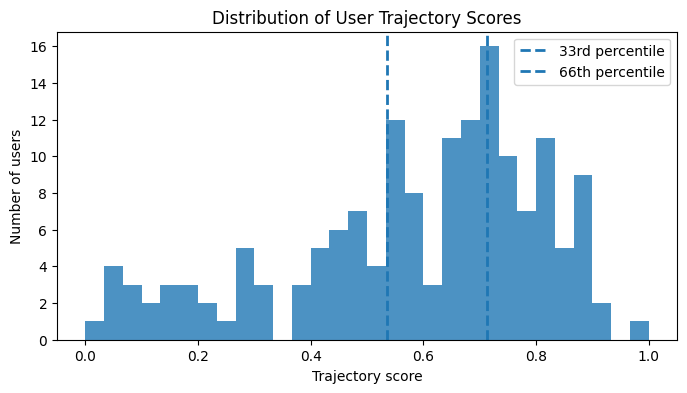

In [9]:
plt.figure(figsize=(8, 4))

plt.hist(
    trajectory_user_df["trajectory_score"],
    bins=30,
    alpha=0.8,
)

plt.axvline(p33, linestyle="--", linewidth=2, label="33rd percentile")
plt.axvline(p66, linestyle="--", linewidth=2, label="66th percentile")

plt.xlabel("Trajectory score")
plt.ylabel("Number of users")
plt.title("Distribution of User Trajectory Scores")
plt.legend()
plt.show()

<Figure size 700x400 with 0 Axes>

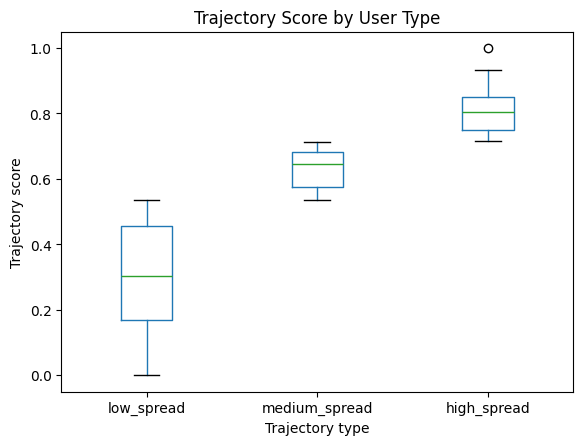

In [10]:
plt.figure(figsize=(7, 4))

trajectory_user_df.boxplot(
    column="trajectory_score",
    by="trajectory_type",
    grid=False,
)

plt.xlabel("Trajectory type")
plt.ylabel("Trajectory score")
plt.title("Trajectory Score by User Type")
plt.suptitle("")
plt.show()

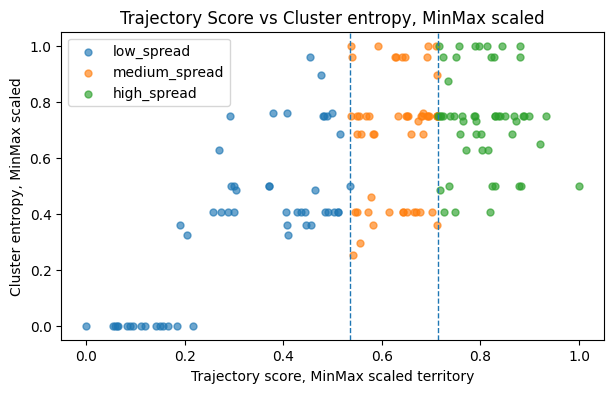

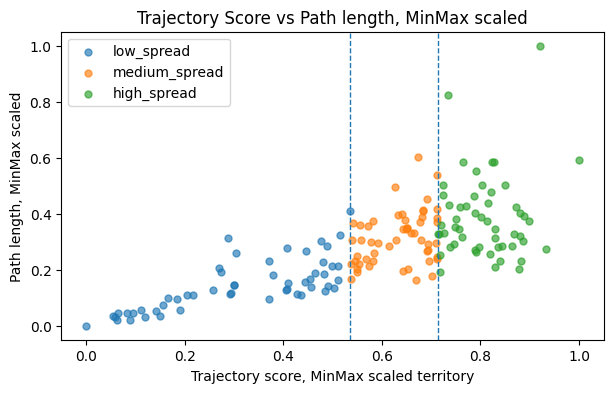

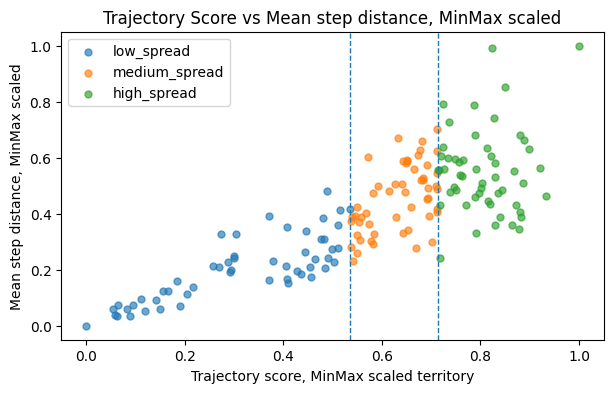

In [11]:
support_feature_labels = {
    "cluster_entropy_scaled": "Cluster entropy, MinMax scaled",
    "path_length_scaled": "Path length, MinMax scaled",
    "mean_step_distance_scaled": "Mean step distance, MinMax scaled",
}

for feature in scaled_support_features:
    plt.figure(figsize=(7, 4))

    for trajectory_type, grp in trajectory_user_df.groupby("trajectory_type", observed=False):
        plt.scatter(
            grp["trajectory_score"],
            grp[feature],
            alpha=0.65,
            s=25,
            label=str(trajectory_type),
        )

    plt.axvline(p33, linestyle="--", linewidth=1)
    plt.axvline(p66, linestyle="--", linewidth=1)
    plt.xlabel("Trajectory score, MinMax scaled territory")
    plt.ylabel(support_feature_labels[feature])
    plt.title(f"Trajectory Score vs {support_feature_labels[feature]}")
    plt.legend()
    plt.show()

<Figure size 700x400 with 0 Axes>

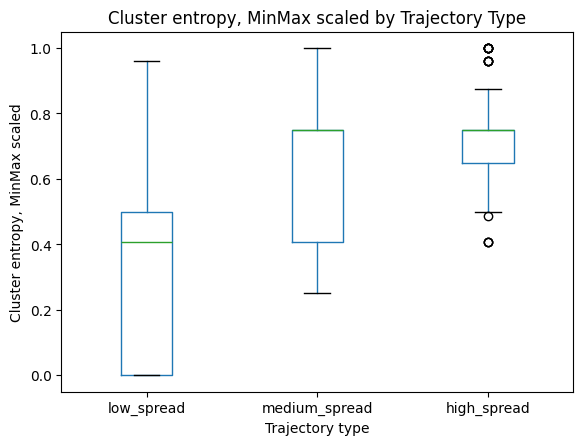

<Figure size 700x400 with 0 Axes>

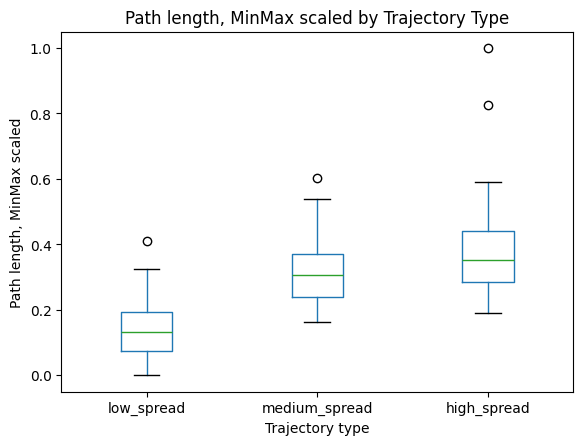

<Figure size 700x400 with 0 Axes>

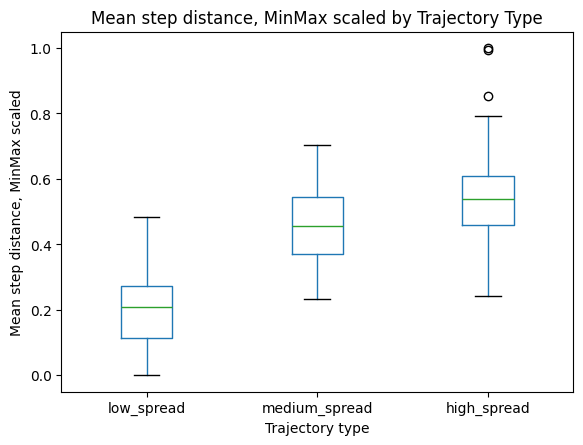

In [12]:
for feature in scaled_support_features:
    plt.figure(figsize=(7, 4))

    trajectory_user_df.boxplot(
        column=feature,
        by="trajectory_type",
        grid=False,
    )

    plt.xlabel("Trajectory type")
    plt.ylabel(support_feature_labels[feature])
    plt.title(f"{support_feature_labels[feature]} by Trajectory Type")
    plt.suptitle("")
    plt.show()